# 2. Análisis Exploratorio de Datos (EDA) - MLOps Pipeline

Este notebook implementa un EDA genérico y reutilizable para cualquier dataset tabular.

**Objetivo**: Explorar, limpiar y analizar los datos de forma sistemática.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configurar el path al directorio raíz del proyecto
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

print(f"Directorio del proyecto: {project_root}")

Directorio del proyecto: c:\Users\Asus\Desktop\Proyecto


## 2.1 Cargar Datos Procesados

In [2]:
# Cargar el DataFrame guardado del notebook anterior
data_path = project_root / 'mlops_pipeline' / 'data' / 'processed' / 'df_raw.pkl'

with open(data_path, 'rb') as f:
    df = pickle.load(f)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 10000 filas x 14 columnas


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2.2 Funciones Genéricas de EDA

### 2.2.1 Exploración Inicial y Limpieza

In [3]:
def caracterizar_datos(df):
    """
    Caracteriza el DataFrame identificando tipos de datos y estadísticas.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a caracterizar
    
    Retorna:
    --------
    dict : Diccionario con información detallada de cada columna
    """
    caracterizacion = {}
    
    for col in df.columns:
        caracterizacion[col] = {
            'tipo_dato': str(df[col].dtype),
            'valores_unicos': df[col].nunique(),
            'valores_nulos': df[col].isnull().sum(),
            'porcentaje_nulos': (df[col].isnull().sum() / len(df)) * 100,
            'primer_valor': df[col].iloc[0] if len(df) > 0 else None
        }
        
        # Clasificar tipo de variable
        if df[col].dtype in ['int64', 'float64']:
            if df[col].nunique() <= 10:
                caracterizacion[col]['tipo_variable'] = 'numérica_discreta'
            else:
                caracterizacion[col]['tipo_variable'] = 'numérica_continua'
        else:
            caracterizacion[col]['tipo_variable'] = 'categórica'
    
    # Crear DataFrame resumen
    df_caracterizacion = pd.DataFrame(caracterizacion).T
    
    print("\n" + "="*80)
    print("CARACTERIZACIÓN DE DATOS")
    print("="*80)
    print(df_caracterizacion)
    
    return caracterizacion

# Ejecutar caracterización
caracterizacion = caracterizar_datos(df)


CARACTERIZACIÓN DE DATOS
                tipo_dato valores_unicos valores_nulos porcentaje_nulos  \
RowNumber           int64          10000             0              0.0   
CustomerId          int64          10000             0              0.0   
Surname            object           2932             0              0.0   
CreditScore         int64            460             0              0.0   
Geography          object              3             0              0.0   
Gender             object              2             0              0.0   
Age                 int64             70             0              0.0   
Tenure              int64             11             0              0.0   
Balance           float64           6382             0              0.0   
NumOfProducts       int64              4             0              0.0   
HasCrCard           int64              2             0              0.0   
IsActiveMember      int64              2             0              0.0   

In [4]:
def unificar_valores_nulos(df, valores_nulos=['N/A', 'n/a', 'NA', 'na', '?', '-', '', ' ', 'None', 'none']):
    """
    Unifica diferentes representaciones de valores nulos a NaN de pandas.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a procesar
    valores_nulos : list
        Lista de valores a considerar como nulos
    
    Retorna:
    --------
    pd.DataFrame : DataFrame con valores nulos unificados
    """
    df_clean = df.copy()
    
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].replace(valores_nulos, np.nan)
    
    nulos_antes = df.isnull().sum().sum()
    nulos_despues = df_clean.isnull().sum().sum()
    
    print(f"\nValores nulos antes: {nulos_antes}")
    print(f"Valores nulos después: {nulos_despues}")
    print(f"Nuevos nulos identificados: {nulos_despues - nulos_antes}")
    
    return df_clean

# Aplicar unificación de nulos
df = unificar_valores_nulos(df)


Valores nulos antes: 0
Valores nulos después: 0
Nuevos nulos identificados: 0


In [5]:
def corregir_tipos_datos(df, tipos_sugeridos=None):
    """
    Detecta y corrige tipos de datos incorrectos.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a procesar
    tipos_sugeridos : dict, opcional
        Diccionario {columna: tipo} para conversiones específicas
    
    Retorna:
    --------
    pd.DataFrame : DataFrame con tipos corregidos
    """
    df_corrected = df.copy()
    
    # Auto-detección de tipos numéricos en columnas object
    for col in df_corrected.select_dtypes(include=['object']).columns:
        try:
            # Intentar convertir a numérico
            df_temp = pd.to_numeric(df_corrected[col], errors='coerce')
            # Si menos del 50% son NaN después de la conversión, es numérico
            if df_temp.isnull().sum() < len(df_corrected) * 0.5:
                df_corrected[col] = df_temp
                print(f"✓ Columna '{col}' convertida a numérica")
        except:
            pass
    
    # Aplicar tipos sugeridos manualmente
    if tipos_sugeridos:
        for col, tipo in tipos_sugeridos.items():
            if col in df_corrected.columns:
                try:
                    df_corrected[col] = df_corrected[col].astype(tipo)
                    print(f"✓ Columna '{col}' convertida a {tipo}")
                except Exception as e:
                    print(f"✗ Error al convertir '{col}' a {tipo}: {str(e)}")
    
    return df_corrected

# Aplicar corrección de tipos
df = corregir_tipos_datos(df)

### 2.2.2 Análisis Univariable


ANÁLISIS UNIVARIABLE - VARIABLES NUMÉRICAS

Estadísticas descriptivas:
                   count          mean           std          min  \
RowNumber        10000.0  5.000500e+03   2886.895680         1.00   
CustomerId       10000.0  1.569094e+07  71936.186123  15565701.00   
CreditScore      10000.0  6.505288e+02     96.653299       350.00   
Age              10000.0  3.892180e+01     10.487806        18.00   
Tenure           10000.0  5.012800e+00      2.892174         0.00   
Balance          10000.0  7.648589e+04  62397.405202         0.00   
NumOfProducts    10000.0  1.530200e+00      0.581654         1.00   
HasCrCard        10000.0  7.055000e-01      0.455840         0.00   
IsActiveMember   10000.0  5.151000e-01      0.499797         0.00   
EstimatedSalary  10000.0  1.000902e+05  57510.492818        11.58   
Exited           10000.0  2.037000e-01      0.402769         0.00   

                         25%           50%           75%          max  
RowNumber            2500.7

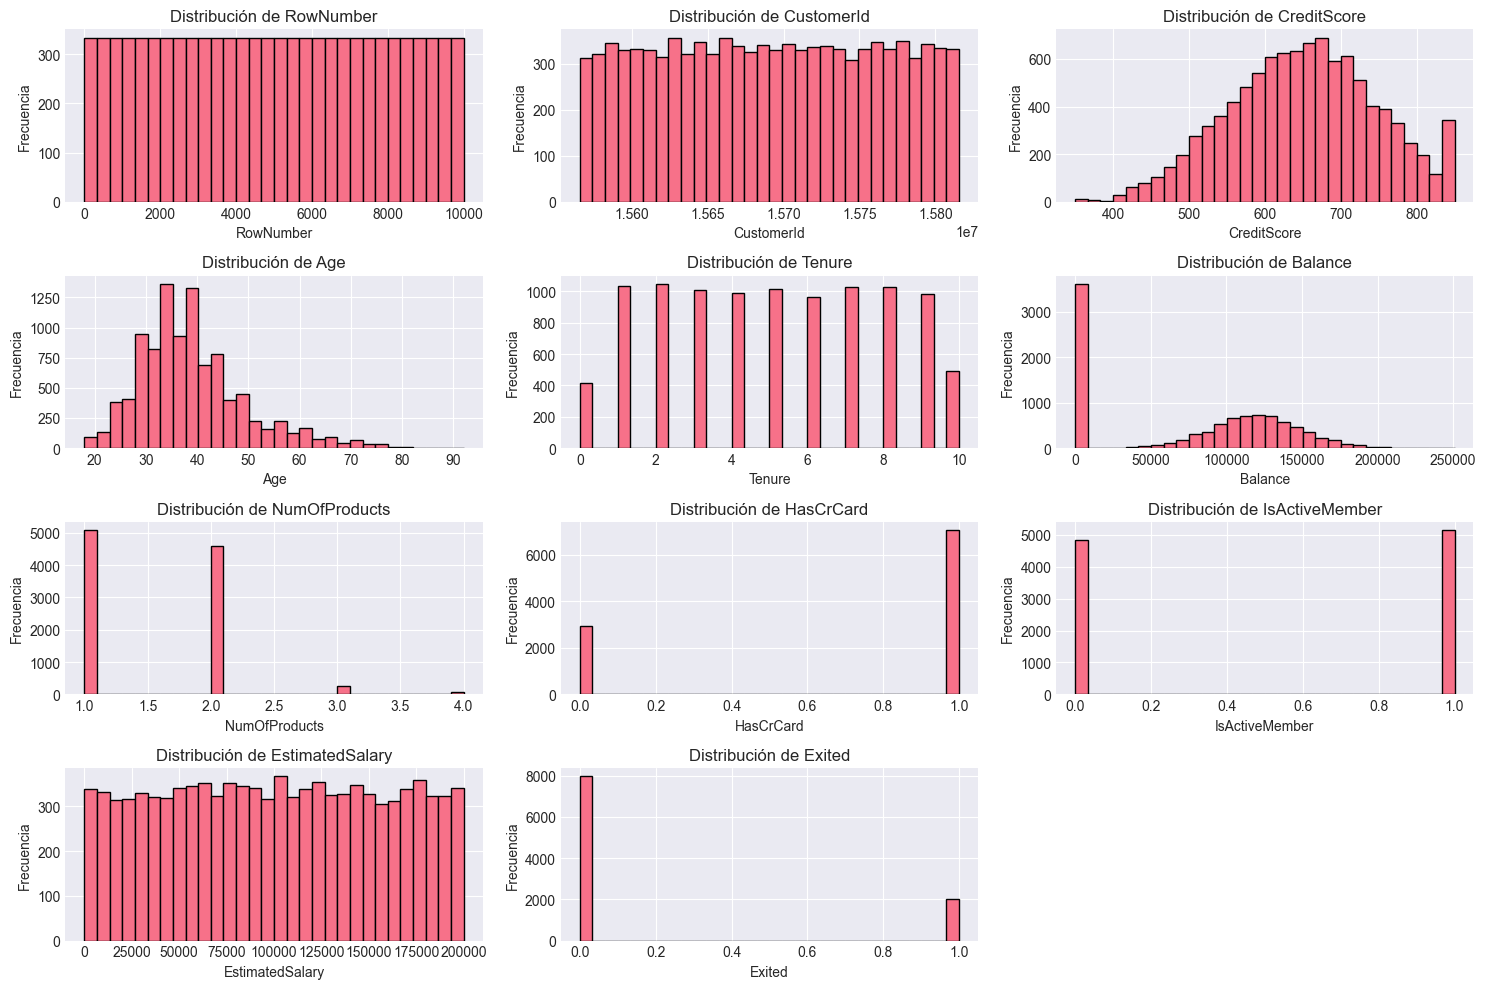

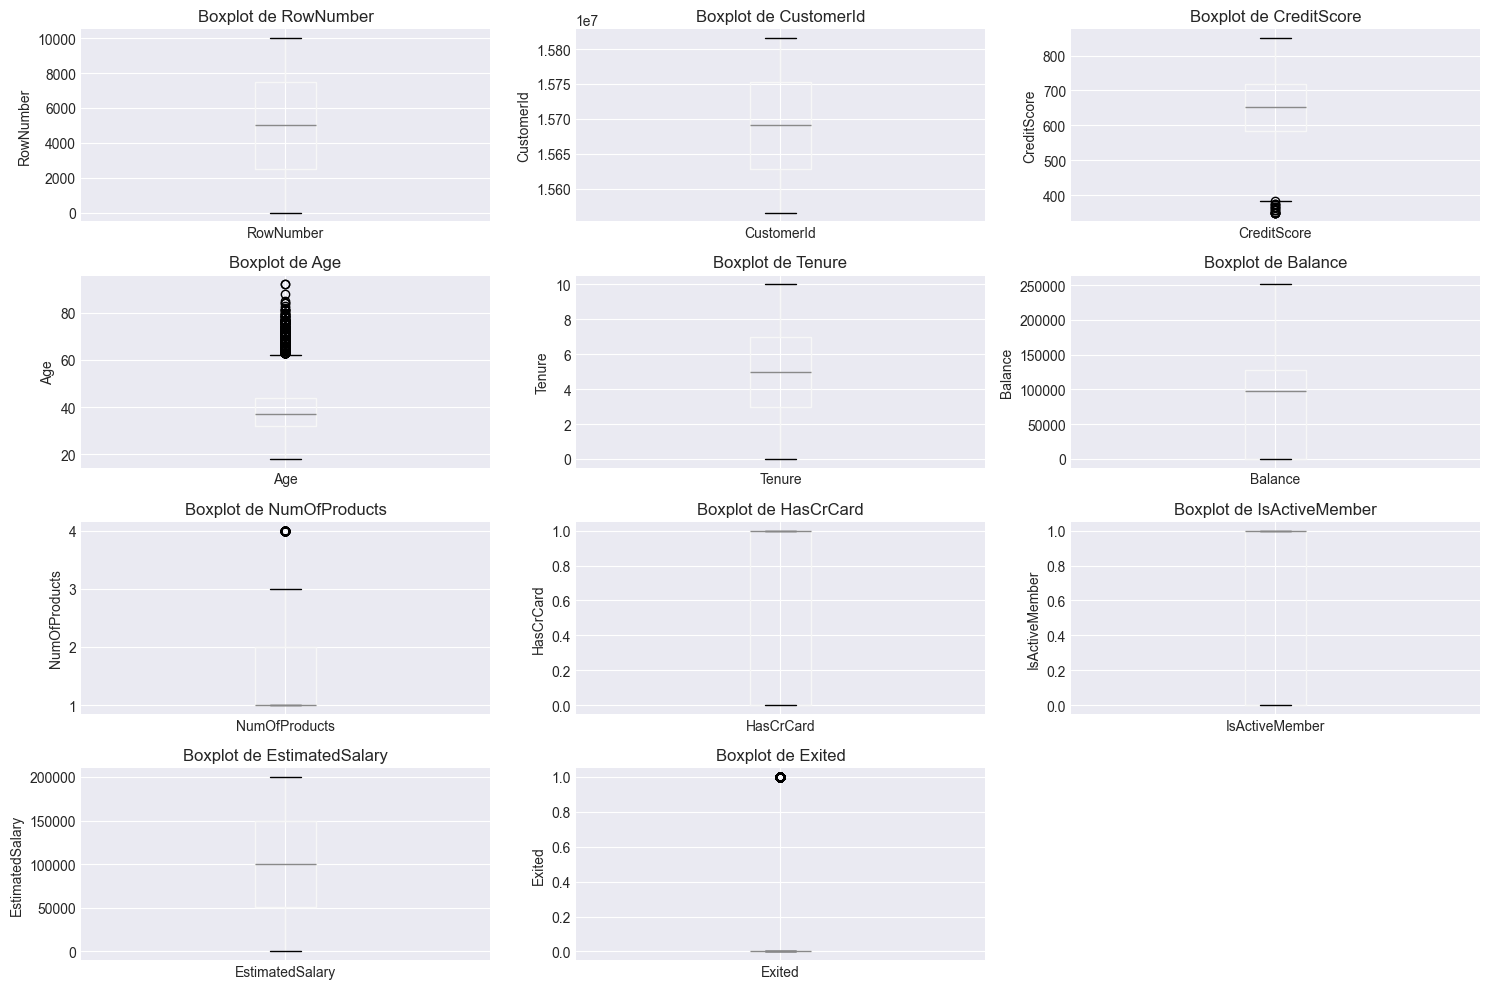

In [6]:
def analisis_univariable_numerico(df, figsize=(15, 10)):
    """
    Análisis univariable de variables numéricas.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar
    figsize : tuple
        Tamaño de la figura
    """
    # Seleccionar columnas numéricas
    cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    
    if len(cols_numericas) == 0:
        print("No hay columnas numéricas para analizar")
        return
    
    # Estadísticas descriptivas
    print("\n" + "="*80)
    print("ANÁLISIS UNIVARIABLE - VARIABLES NUMÉRICAS")
    print("="*80)
    print("\nEstadísticas descriptivas:")
    print(df[cols_numericas].describe().T)
    
    # Histogramas
    n_cols = 3
    n_rows = (len(cols_numericas) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if len(cols_numericas) > 1 else [axes]
    
    for idx, col in enumerate(cols_numericas):
        df[col].hist(bins=30, ax=axes[idx], edgecolor='black')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')
    
    # Ocultar ejes vacíos
    for idx in range(len(cols_numericas), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Boxplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if len(cols_numericas) > 1 else [axes]
    
    for idx, col in enumerate(cols_numericas):
        df.boxplot(column=col, ax=axes[idx])
        axes[idx].set_title(f'Boxplot de {col}')
        axes[idx].set_ylabel(col)
    
    # Ocultar ejes vacíos
    for idx in range(len(cols_numericas), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Ejecutar análisis univariable numérico
analisis_univariable_numerico(df)


ANÁLISIS UNIVARIABLE - VARIABLES CATEGÓRICAS

Variable: Surname

Frecuencias:
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Yeh         25
Genovese    25
Shih        25
Wright      24
Maclean     24
Ma          23
Wilson      23
Fanucci     23
White       23
Johnson     22
Lu          22
Moore       22
Chu         22
Wang        22
Thompson    21
Name: count, dtype: int64


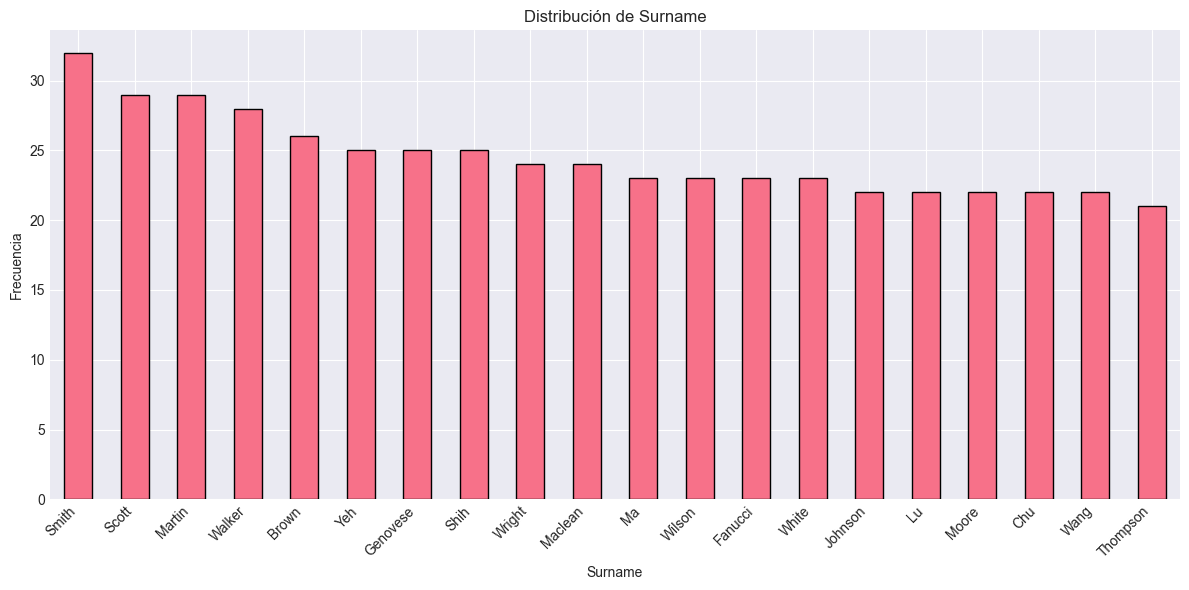


Variable: Geography

Frecuencias:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


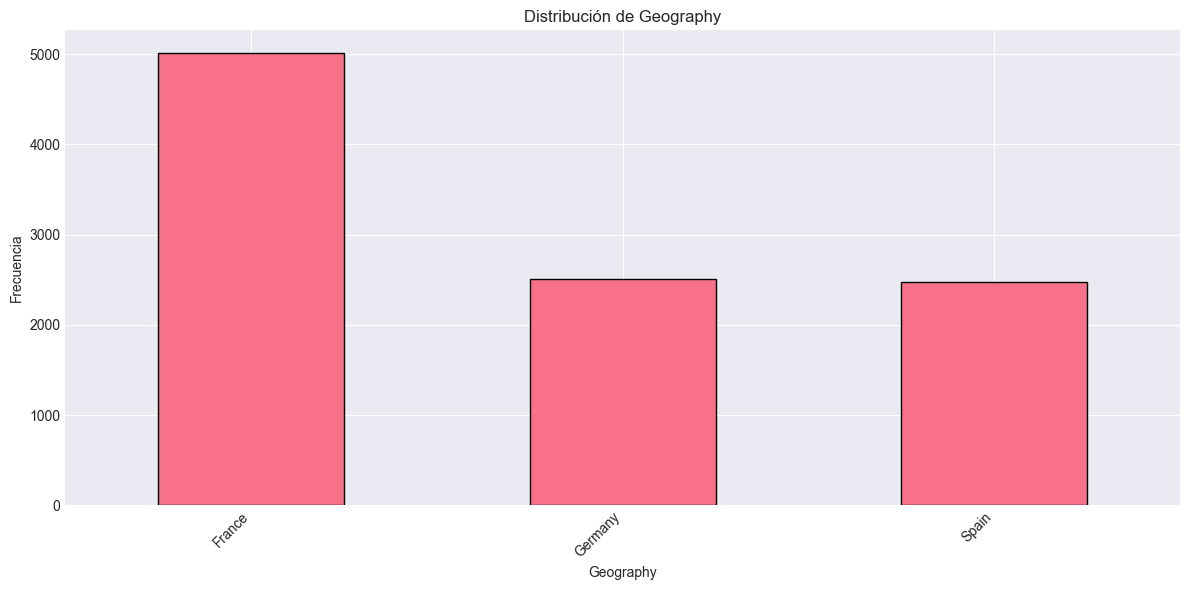


Variable: Gender

Frecuencias:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


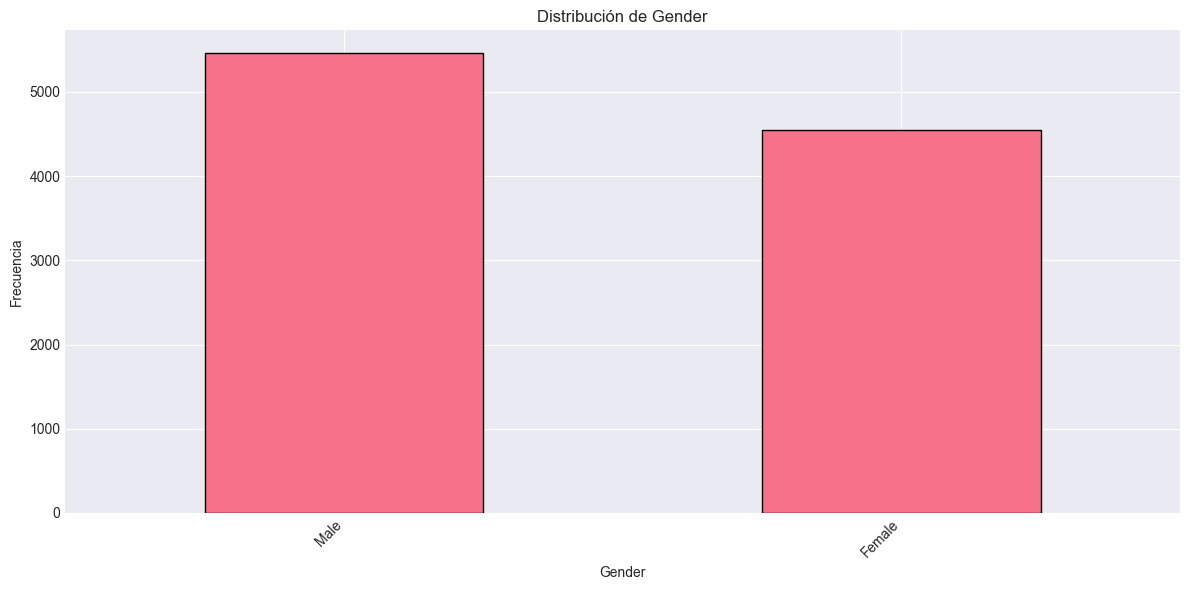

In [7]:
def analisis_univariable_categorico(df, max_categorias=20, figsize=(15, 10)):
    """
    Análisis univariable de variables categóricas.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar
    max_categorias : int
        Número máximo de categorías a mostrar
    figsize : tuple
        Tamaño de la figura
    """
    # Seleccionar columnas categóricas
    cols_categoricas = df.select_dtypes(include=['object', 'category']).columns
    
    if len(cols_categoricas) == 0:
        print("No hay columnas categóricas para analizar")
        return
    
    print("\n" + "="*80)
    print("ANÁLISIS UNIVARIABLE - VARIABLES CATEGÓRICAS")
    print("="*80)
    
    for col in cols_categoricas:
        print(f"\n{'='*60}")
        print(f"Variable: {col}")
        print(f"{'='*60}")
        
        value_counts = df[col].value_counts().head(max_categorias)
        print(f"\nFrecuencias:")
        print(value_counts)
        
        # Gráfico de barras
        plt.figure(figsize=(12, 6))
        value_counts.plot(kind='bar', edgecolor='black')
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Ejecutar análisis univariable categórico
analisis_univariable_categorico(df)

### 2.2.3 Análisis Bivariable


Variable objetivo identificada: 'Exited'

ANÁLISIS BIVARIABLE - Respecto a 'Exited'

1. Variables numéricas vs Variable objetivo


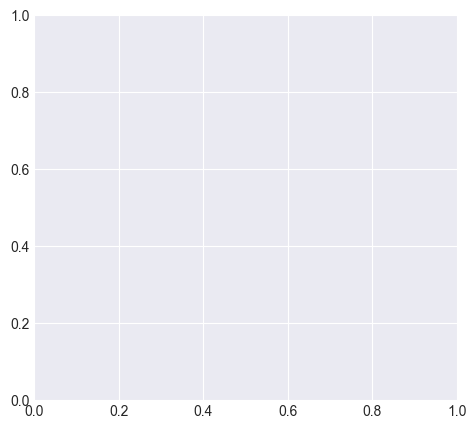

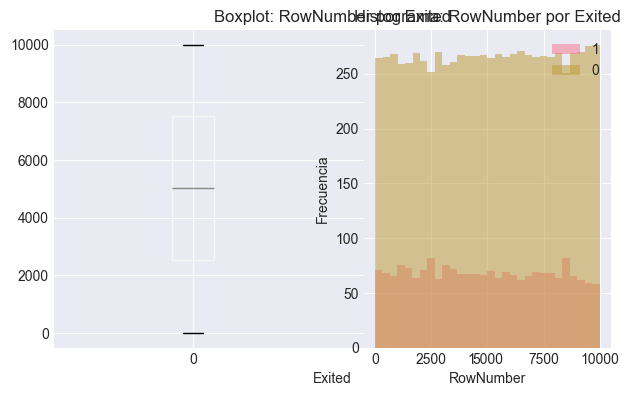

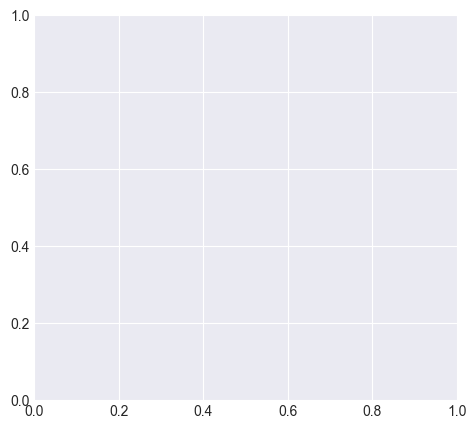

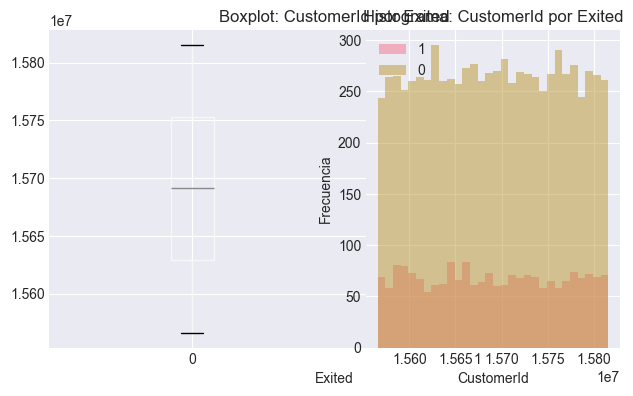

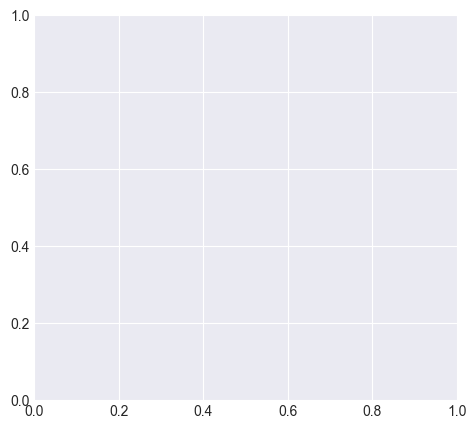

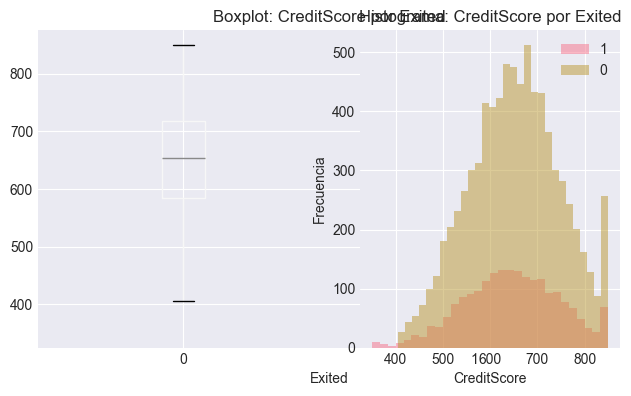

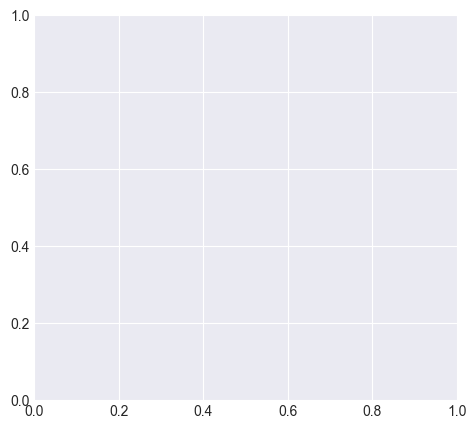

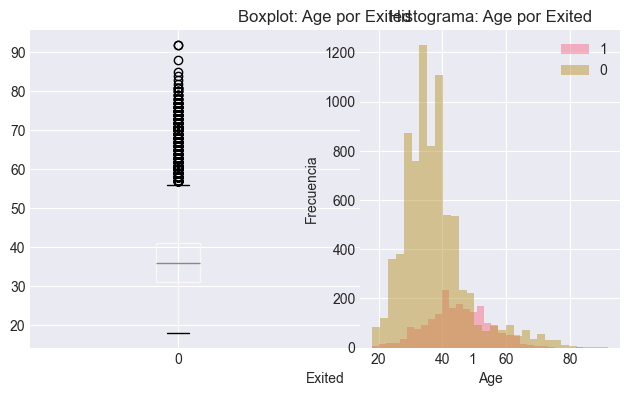

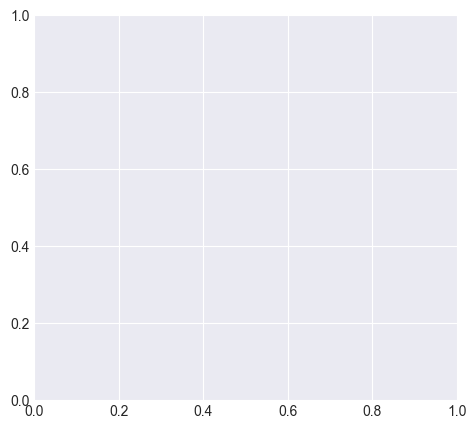

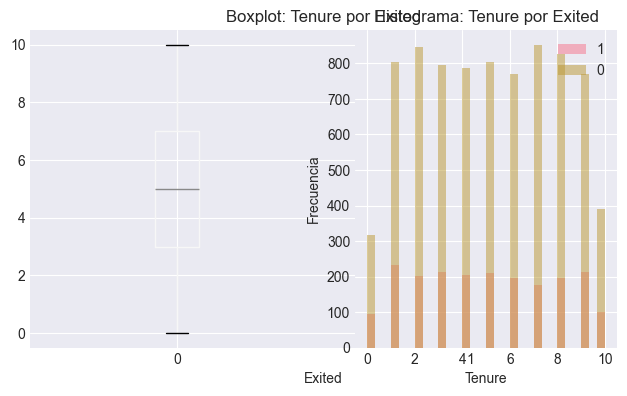

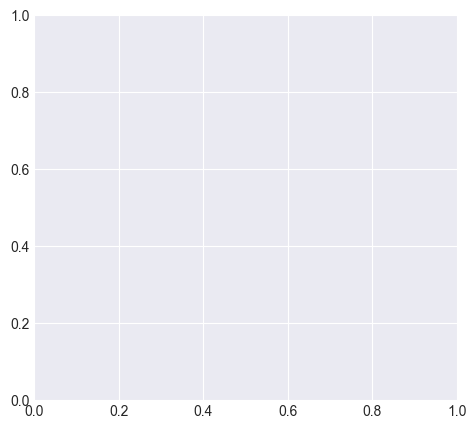

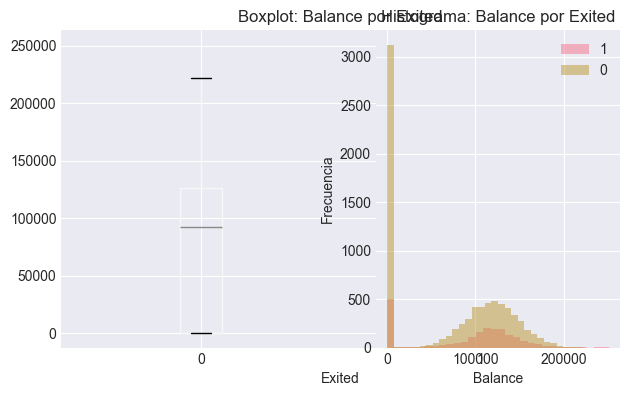

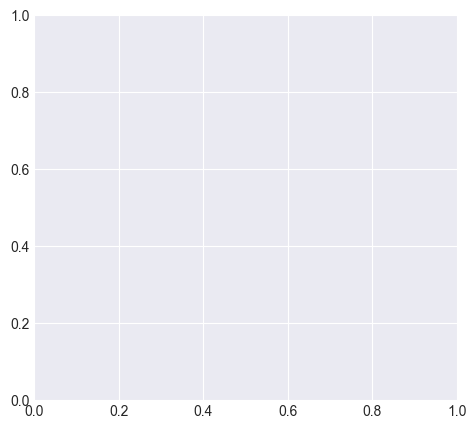

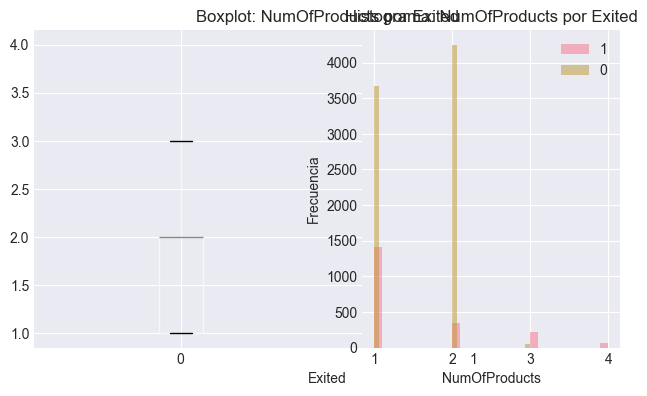

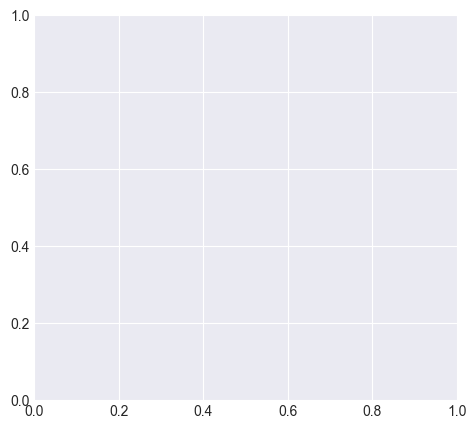

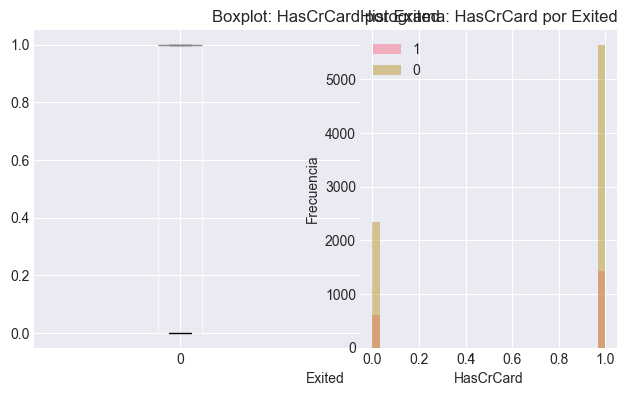

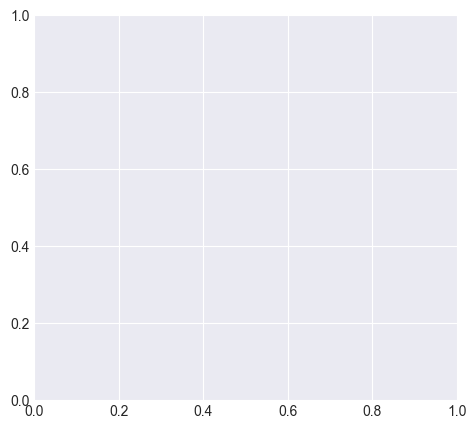

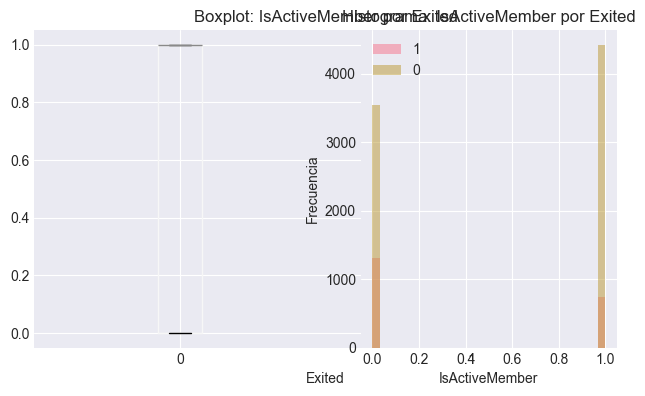

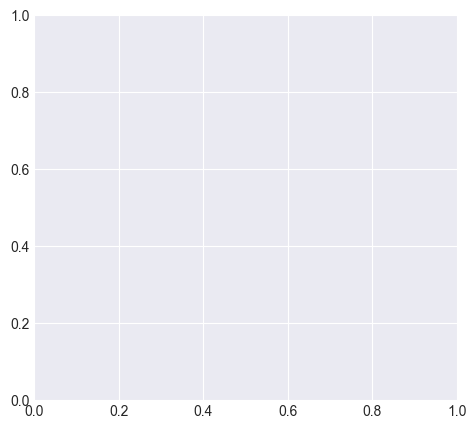

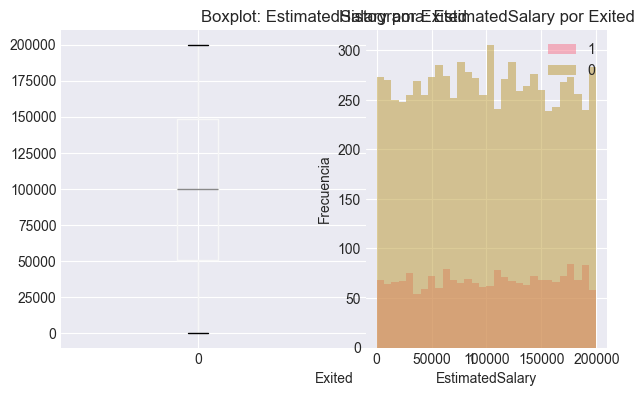


2. Variables categóricas vs Variable objetivo


<Figure size 1200x500 with 0 Axes>

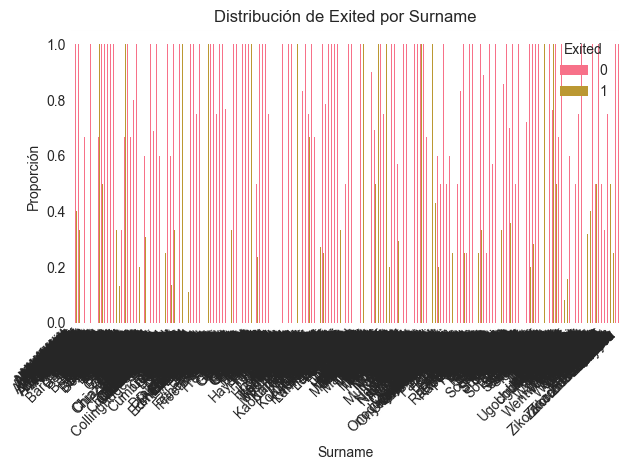

<Figure size 1200x500 with 0 Axes>

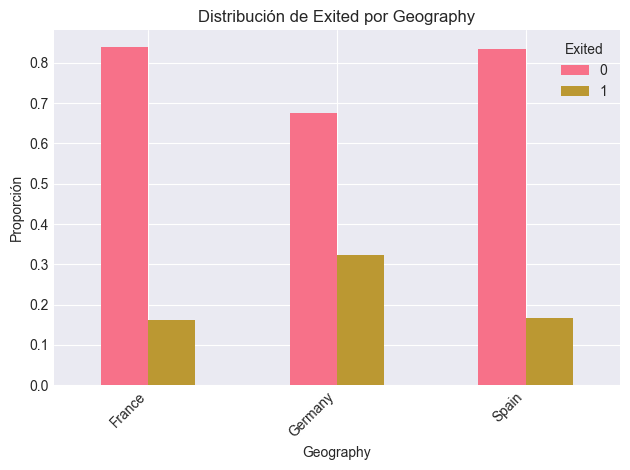

<Figure size 1200x500 with 0 Axes>

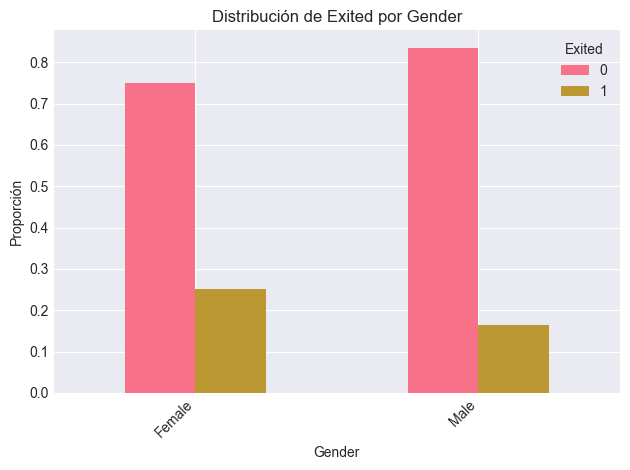

In [8]:
def analisis_bivariable_con_objetivo(df, variable_objetivo):
    """
    Análisis bivariable de todas las variables respecto a la variable objetivo.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar
    variable_objetivo : str
        Nombre de la variable objetivo
    """
    if variable_objetivo not in df.columns:
        print(f"✗ La variable '{variable_objetivo}' no existe en el DataFrame")
        return
    
    print("\n" + "="*80)
    print(f"ANÁLISIS BIVARIABLE - Respecto a '{variable_objetivo}'")
    print("="*80)
    
    # Análisis con variables numéricas
    cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    cols_numericas = [col for col in cols_numericas if col != variable_objetivo]
    
    if len(cols_numericas) > 0:
        print("\n1. Variables numéricas vs Variable objetivo")
        
        for col in cols_numericas:
            plt.figure(figsize=(12, 5))
            
            # Si la variable objetivo es binaria o tiene pocos valores
            if df[variable_objetivo].nunique() <= 10:
                plt.subplot(1, 2, 1)
                df.boxplot(column=col, by=variable_objetivo)
                plt.title(f'Boxplot: {col} por {variable_objetivo}')
                plt.suptitle('')
                
                plt.subplot(1, 2, 2)
                for value in df[variable_objetivo].unique():
                    df[df[variable_objetivo] == value][col].hist(alpha=0.5, label=str(value), bins=30)
                plt.title(f'Histograma: {col} por {variable_objetivo}')
                plt.xlabel(col)
                plt.ylabel('Frecuencia')
                plt.legend()
            else:
                # Variable objetivo continua - scatter plot
                plt.scatter(df[col], df[variable_objetivo], alpha=0.5)
                plt.title(f'Scatter: {col} vs {variable_objetivo}')
                plt.xlabel(col)
                plt.ylabel(variable_objetivo)
            
            plt.tight_layout()
            plt.show()
    
    # Análisis con variables categóricas
    cols_categoricas = df.select_dtypes(include=['object', 'category']).columns
    cols_categoricas = [col for col in cols_categoricas if col != variable_objetivo]
    
    if len(cols_categoricas) > 0:
        print("\n2. Variables categóricas vs Variable objetivo")
        
        for col in cols_categoricas:
            # Tabla de contingencia
            ct = pd.crosstab(df[col], df[variable_objetivo], normalize='index')
            
            plt.figure(figsize=(12, 5))
            ct.plot(kind='bar', stacked=False)
            plt.title(f'Distribución de {variable_objetivo} por {col}')
            plt.xlabel(col)
            plt.ylabel('Proporción')
            plt.legend(title=variable_objetivo)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

# Definir variable objetivo (ajustar según el dataset)
# Para Churn_Modelling.csv, la variable objetivo es 'Exited'
variable_objetivo = 'Exited' if 'Exited' in df.columns else df.columns[-1]
print(f"\nVariable objetivo identificada: '{variable_objetivo}'")

# Ejecutar análisis bivariable
analisis_bivariable_con_objetivo(df, variable_objetivo)

### 2.2.4 Matriz de Correlación


MATRIZ DE CORRELACIÓN (PEARSON)


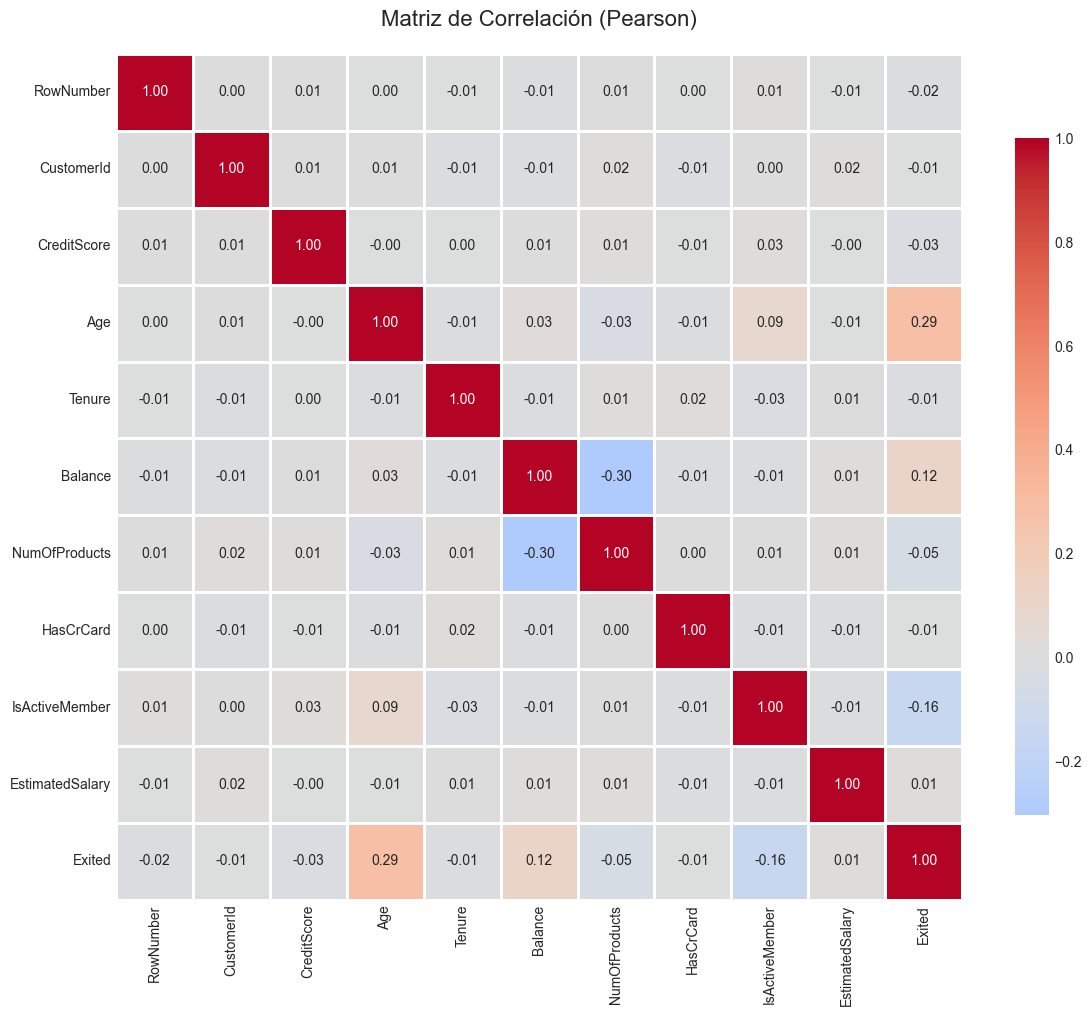


Correlaciones fuertes (|r| > 0.7):
  No se encontraron correlaciones fuertes


In [9]:
def matriz_correlacion(df, metodo='pearson', figsize=(12, 10)):
    """
    Genera y visualiza la matriz de correlación.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar
    metodo : str
        Método de correlación ('pearson', 'spearman', 'kendall')
    figsize : tuple
        Tamaño de la figura
    """
    # Seleccionar solo columnas numéricas
    df_numeric = df.select_dtypes(include=['int64', 'float64'])
    
    if len(df_numeric.columns) < 2:
        print("No hay suficientes variables numéricas para calcular correlaciones")
        return
    
    # Calcular matriz de correlación
    corr_matrix = df_numeric.corr(method=metodo)
    
    print("\n" + "="*80)
    print(f"MATRIZ DE CORRELACIÓN ({metodo.upper()})")
    print("="*80)
    
    # Visualizar matriz de correlación
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(f'Matriz de Correlación ({metodo.capitalize()})', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Identificar correlaciones fuertes
    print("\nCorrelaciones fuertes (|r| > 0.7):")
    correlaciones_fuertes = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                correlaciones_fuertes.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    if correlaciones_fuertes:
        for var1, var2, corr in correlaciones_fuertes:
            print(f"  - {var1} <-> {var2}: {corr:.3f}")
    else:
        print("  No se encontraron correlaciones fuertes")
    
    return corr_matrix

# Generar matriz de correlación
corr_matrix = matriz_correlacion(df)

## 2.3 Reglas de Validación de Datos

In [10]:
def definir_reglas_validacion(df):
    """
    Define reglas de validación basadas en el análisis del DataFrame.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame analizado
    
    Retorna:
    --------
    dict : Diccionario con reglas de validación
    """
    import json
    import numpy as np
    
    def convert_to_serializable(obj):
        """Convierte objetos NumPy a tipos nativos de Python."""
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, tuple):
            return list(obj)
        elif pd.isna(obj):
            return None
        return obj
    
    reglas = {}
    
    for col in df.columns:
        reglas[col] = {
            'tipo_dato': str(df[col].dtype),
            'permite_nulos': bool(df[col].isnull().any()),
            'valores_unicos': int(df[col].nunique())
        }
        
        if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
            reglas[col]['rango_valido'] = (
                convert_to_serializable(df[col].min()),
                convert_to_serializable(df[col].max())
            )
            reglas[col]['media'] = convert_to_serializable(df[col].mean())
            reglas[col]['desviacion'] = convert_to_serializable(df[col].std())
        else:
            categorias = df[col].dropna().unique().tolist()[:50]
            reglas[col]['categorias_validas'] = [convert_to_serializable(cat) for cat in categorias]
    
    print("\n" + "="*80)
    print("REGLAS DE VALIDACIÓN DE DATOS")
    print("="*80)
    
    for col, regla in reglas.items():
        print(f"\n{col}:")
        for key, value in regla.items():
            if key != 'categorias_validas' or len(str(value)) < 200:
                print(f"  - {key}: {value}")
    
    # Guardar reglas
    reglas_path = project_root / 'mlops_pipeline' / 'data' / 'processed' / 'reglas_validacion.json'
    reglas_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Convertir tipos no serializables
    reglas_serializables = {}
    for col, regla in reglas.items():
        reglas_serializables[col] = {}
        for key, value in regla.items():
            reglas_serializables[col][key] = convert_to_serializable(value)
    
    with open(reglas_path, 'w', encoding='utf-8') as f:
        json.dump(reglas_serializables, f, indent=2, ensure_ascii=False)
    
    print(f"\n✓ Reglas de validación guardadas en: {reglas_path}")
    
    return reglas

## 2.4 Identificación de Transformaciones y Atributos Derivados

In [11]:
def identificar_transformaciones(df):
    """
    Identifica transformaciones necesarias y posibles atributos derivados.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar
    
    Retorna:
    --------
    dict : Diccionario con transformaciones sugeridas
    """
    transformaciones = {
        'escalado': [],
        'encoding': [],
        'imputacion': [],
        'atributos_derivados': []
    }
    
    # Variables numéricas que necesitan escalado
    cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    for col in cols_numericas:
        if df[col].std() > 1000 or (df[col].max() - df[col].min()) > 1000:
            transformaciones['escalado'].append({
                'columna': col,
                'razon': 'Gran rango de valores',
                'metodo_sugerido': 'StandardScaler o MinMaxScaler'
            })
    
    # Variables categóricas que necesitan encoding
    cols_categoricas = df.select_dtypes(include=['object', 'category']).columns
    for col in cols_categoricas:
        n_unique = df[col].nunique()
        if n_unique == 2:
            transformaciones['encoding'].append({
                'columna': col,
                'categorias': n_unique,
                'metodo_sugerido': 'LabelEncoder o Binary Encoding'
            })
        elif n_unique <= 10:
            transformaciones['encoding'].append({
                'columna': col,
                'categorias': n_unique,
                'metodo_sugerido': 'OneHotEncoder'
            })
        else:
            transformaciones['encoding'].append({
                'columna': col,
                'categorias': n_unique,
                'metodo_sugerido': 'TargetEncoder o FrequencyEncoder'
            })
    
    # Columnas con valores nulos que necesitan imputación
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                transformaciones['imputacion'].append({
                    'columna': col,
                    'nulos': df[col].isnull().sum(),
                    'metodo_sugerido': 'Mediana o KNN Imputer'
                })
            else:
                transformaciones['imputacion'].append({
                    'columna': col,
                    'nulos': df[col].isnull().sum(),
                    'metodo_sugerido': 'Moda o Categoría "Desconocido"'
                })
    
    # Sugerencias de atributos derivados (específico para cada dataset)
    # Ejemplo genérico
    if 'Age' in df.columns:
        transformaciones['atributos_derivados'].append({
            'nombre': 'AgeGroup',
            'descripcion': 'Categorías de edad',
            'fuente': 'Age'
        })
    
    print("\n" + "="*80)
    print("TRANSFORMACIONES IDENTIFICADAS")
    print("="*80)
    
    for categoria, items in transformaciones.items():
        if items:
            print(f"\n{categoria.upper().replace('_', ' ')}:")
            for item in items:
                print(f"  - {item}")
    
    # Guardar transformaciones
    import json
    trans_path = project_root / 'mlops_pipeline' / 'data' / 'processed' / 'transformaciones_sugeridas.json'
    with open(trans_path, 'w') as f:
        json.dump(transformaciones, f, indent=2)
    
    print(f"\n✓ Transformaciones guardadas en: {trans_path}")
    
    return transformaciones

# Identificar transformaciones
transformaciones = identificar_transformaciones(df)


TRANSFORMACIONES IDENTIFICADAS

ESCALADO:
  - {'columna': 'RowNumber', 'razon': 'Gran rango de valores', 'metodo_sugerido': 'StandardScaler o MinMaxScaler'}
  - {'columna': 'CustomerId', 'razon': 'Gran rango de valores', 'metodo_sugerido': 'StandardScaler o MinMaxScaler'}
  - {'columna': 'Balance', 'razon': 'Gran rango de valores', 'metodo_sugerido': 'StandardScaler o MinMaxScaler'}
  - {'columna': 'EstimatedSalary', 'razon': 'Gran rango de valores', 'metodo_sugerido': 'StandardScaler o MinMaxScaler'}

ENCODING:
  - {'columna': 'Surname', 'categorias': 2932, 'metodo_sugerido': 'TargetEncoder o FrequencyEncoder'}
  - {'columna': 'Geography', 'categorias': 3, 'metodo_sugerido': 'OneHotEncoder'}
  - {'columna': 'Gender', 'categorias': 2, 'metodo_sugerido': 'LabelEncoder o Binary Encoding'}

ATRIBUTOS DERIVADOS:
  - {'nombre': 'AgeGroup', 'descripcion': 'Categorías de edad', 'fuente': 'Age'}

✓ Transformaciones guardadas en: c:\Users\Asus\Desktop\Proyecto\mlops_pipeline\data\processed\tra

## 2.5 Resumen Final del EDA

In [12]:
print("\n" + "="*80)
print("RESUMEN FINAL DEL EDA")
print("="*80)
print(f"\nDataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nVariables numéricas: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Variables categóricas: {len(df.select_dtypes(include=['object', 'category']).columns)}")
print(f"\nValores nulos totales: {df.isnull().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\n✓ EDA completado exitosamente")
print(f"✓ Reglas de validación definidas")
print(f"✓ Transformaciones identificadas")
print(f"\nPróximo paso: Feature Engineering (ft_engineering.py)")


RESUMEN FINAL DEL EDA

Dataset: 10000 filas x 14 columnas

Variables numéricas: 11
Variables categóricas: 3

Valores nulos totales: 0
Filas duplicadas: 0

✓ EDA completado exitosamente
✓ Reglas de validación definidas
✓ Transformaciones identificadas

Próximo paso: Feature Engineering (ft_engineering.py)


## 2.6 Guardar DataFrame Procesado

In [13]:
# Guardar DataFrame después del EDA
output_path = project_root / 'mlops_pipeline' / 'data' / 'processed' / 'df_after_eda.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(df, f)

print(f"\n✓ DataFrame guardado en: {output_path}")


✓ DataFrame guardado en: c:\Users\Asus\Desktop\Proyecto\mlops_pipeline\data\processed\df_after_eda.pkl
